In [1]:
import numpy as np
import pandas as pd

In [2]:
retail = pd.read_csv("../retailFiles/retail_2016_2017.csv", parse_dates=["date"])
retail.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [3]:
retail_agg = retail.groupby(["date"]).agg({"sales":"sum"}).round().iloc[:10]
retail_agg

,sales
date,
2016-01-01,16433.0
2016-01-02,1066677.0
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,835320.0
2016-01-06,821686.0
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


In [4]:
retail_agg.iloc[1] = np.nan
retail_agg.iloc[4:6] = np.nan 
retail_agg

,sales
date,
2016-01-01,16433.0
2016-01-02,NaN
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


<Axes: xlabel='date'>

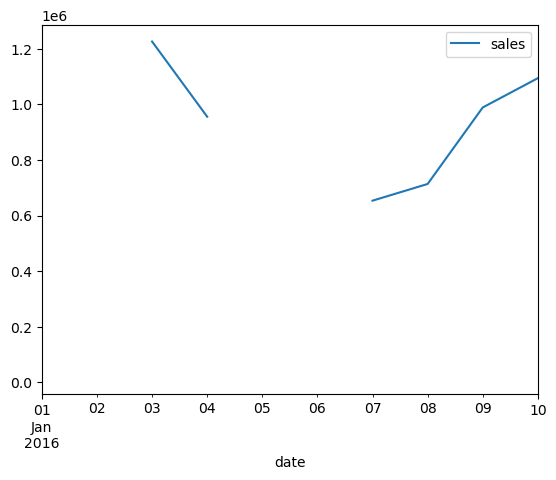

In [5]:
retail_agg.plot()

In [6]:
retail_agg.fillna(retail_agg["sales"].mean()) # fill NaN with mean of the column

,sales
date,
2016-01-01,16433.0
2016-01-02,807163.0
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,807163.0
2016-01-06,807163.0
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


<Axes: xlabel='date'>

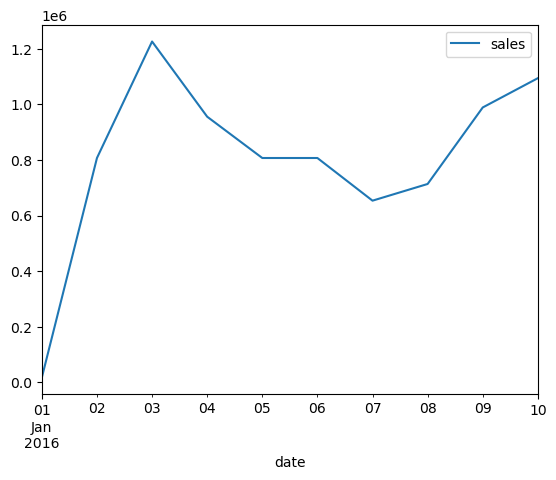

In [7]:
retail_agg.fillna(retail_agg["sales"].mean()).plot()

In [8]:
retail_agg.ffill() # fill NaN with the value above it

,sales
date,
2016-01-01,16433.0
2016-01-02,16433.0
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,955957.0
2016-01-06,955957.0
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


<Axes: xlabel='date'>

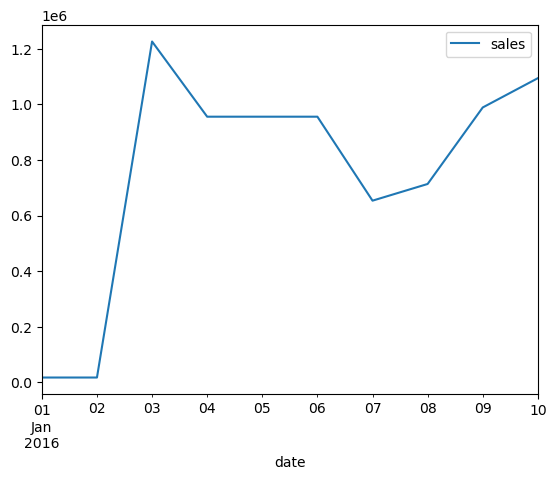

In [9]:
retail_agg.ffill().plot()

In [10]:
retail_agg.bfill() # fill NaN with value below it

,sales
date,
2016-01-01,16433.0
2016-01-02,1226736.0
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,653504.0
2016-01-06,653504.0
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


<Axes: xlabel='date'>

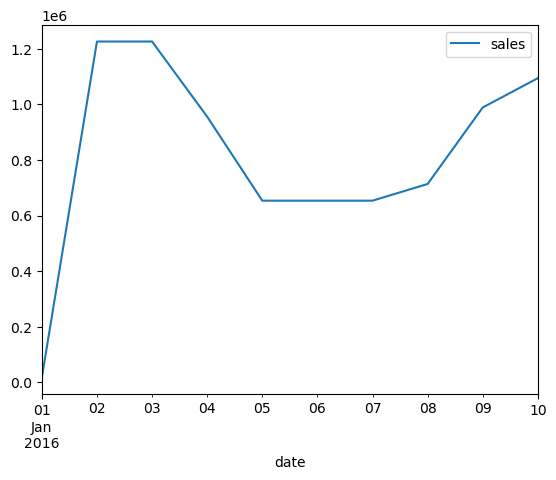

In [11]:
retail_agg.bfill().plot()

In [12]:
retail_agg.interpolate().round() # Use the values of the above and the below values of NaN and find the average of those values

,sales
date,
2016-01-01,16433.0
2016-01-02,621584.0
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,855139.0
2016-01-06,754322.0
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


<Axes: xlabel='date'>

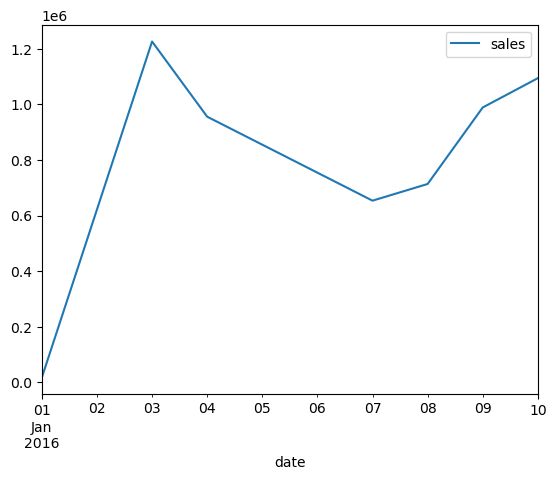

In [13]:
retail_agg.interpolate().round().plot()